# DAY2 — 로그 IQR / PLS 비교

ΔQ100−10(V)의 표현만 변경한다. 기존 셀 제외·개발28/Hold-out8·동일5fold·seed42를 유지한다. 타깃은 원 cycle_life, IQR은 특징1개, PLS는 고정 전압100지점과 성분1~3개이다.

표준화·PLS 압축은 각 CV 학습 폴드에서만 fit했다. IQR과 PLS 대표를 Batch1 CV로 먼저 고정한 뒤 평가했다. 아래 셀은 저장된 결과를 읽으며 학습·평가를 반복하지 않는다.

문헌: [Attia et al. (2021)](https://arxiv.org/abs/2101.01885). 논문은 혼합 배치 분할·로그 수명·RMSE로 평가하여 정확한 재현 비교가 아니다.

**보고서 연결:** 이 노트북은 해당 실험 단계의 실행 기록이다. 기존 셀 분리와 프로토콜 분리 결과를 함께 해석한 전체 결론은 [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)에 있다.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
if not (root / "outputs/day2").exists():
    root = root.parent
out = root / "outputs/day2/curve_models"
results = json.loads((out / "results.json").read_text())
cv = pd.read_csv(out / "cv_comparison.csv")
display(cv.round(3))
print("PLS 대표:", results["pls_selected"], "; 이번 비교 CV 선택:", results["selected"])

,candidate,components,input_features,cv_mape_pct,cv_std_pp
0,linear_iqr,0,1,9.123,2.632
1,pls_1,1,100,10.283,2.571
2,pls_2,2,100,12.031,5.672
3,pls_3,3,100,10.584,5.287


PLS 대표: pls_1 ; 이번 비교 CV 선택: linear_iqr


성분 수는1·2·3개만 비교했고 CV 최저와0.1%p 이내라면 더 적은 성분을 사용하는 규칙을 사전에 정했다. PLS1의 CV가 가장 낮았다. IQR CV 개선은0.161%p로 작으며 통계적으로 유의한 개선이라고 단정하지 않는다.

,candidate,cv_mape_pct,holdout_mape_pct,holdout_bias_cycles,batch2_mape_pct,batch2_bias_cycles
0,linear_variance,9.285,6.439,-24.479,26.186,119.485
1,linear_iqr,9.123,5.725,-22.820,30.565,155.941
2,pls_1,10.283,8.209,-31.254,29.433,94.386


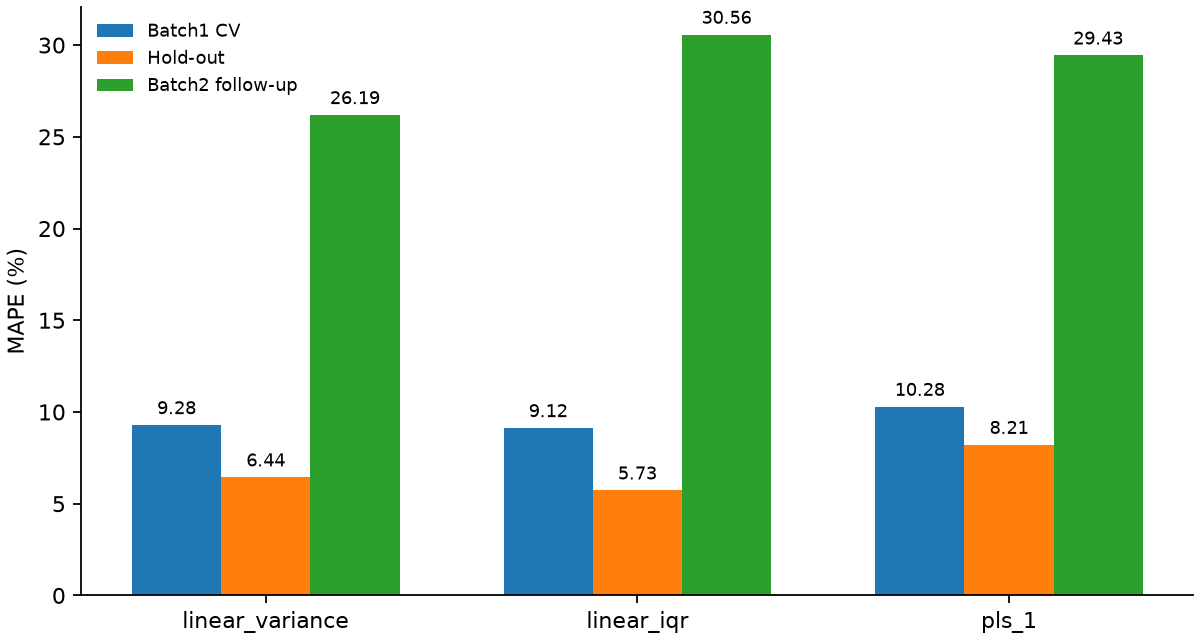

In [2]:
comparison = pd.read_csv(out / "comparison.csv")
display(comparison.round(3))
display(Image(filename=str(out / "comparison.png")))

In [3]:
segments = pd.read_csv(out / "segments.csv")
display(segments.loc[segments.evaluation.eq("Test (Batch 2)")].round(3))
display(pd.read_csv(out / "performance_reporting.csv").round(3))

,candidate,evaluation,life_band,n,mape_pct,bias_cycles
0,linear_iqr,Test (Batch 2),<=500,28,32.814,146.153
1,linear_iqr,Test (Batch 2),500-1000,8,31.668,230.832
2,linear_iqr,Test (Batch 2),>1000,3,6.634,47.581
5,linear_variance,Test (Batch 2),<=500,28,29.389,130.501
6,linear_variance,Test (Batch 2),500-1000,8,22.484,152.350
7,linear_variance,Test (Batch 2),>1000,3,6.157,-70.966
10,pls_1,Test (Batch 2),<=500,28,33.559,119.058
11,pls_1,Test (Batch 2),500-1000,8,20.141,110.734
12,pls_1,Test (Batch 2),>1000,3,15.709,-179.484


,구분,MAPE (%),비고
0,Train (Batch 1 CV),9.123,5-fold mean; development28
1,Valid (Batch 1 Hold-out),5.725,Same model; 8 cells
2,Test (Batch 2),30.565,Exploratory follow-up; 39 cells
3,Gap (Train-Valid),-3.398,"Valid - CV, percentage points"
4,Gap (Valid-Test),24.840,"Batch2 - Valid, percentage points"
5,Gap (Target-Test),21.465,"Batch2 - 9.1%, assignment reference"


## 결론

- 기존 분산: CV9.285%, Hold-out6.439%, Batch2 **26.186%**.
- 로그 IQR: CV9.123%, Hold-out5.725%, Batch2 **30.565%**. 내부 개선이 외부 개선으로 이어지지 않았다.
- PLS1: CV10.283%, Hold-out8.209%, Batch2 **29.433%**. 성분 수 증가의 내부 개선은 확인되지 않았다.
- PLS의 평균 과대 예측은119.49→94.39사이클로 감소했지만 MAPE는 악화했다. 중간 수명 구간은 개선됐으나500이하 다수 셀의 상대 오차는 커졌다.
- 이번 방법은 기존26.19%를 넘지 못했다. Batch2가 낮은 후보로 사후 재선택하지 않고, 이전 최종 후보를 자동으로 교체하지 않는다.
- Batch2는 이미 여러 실험에서 확인한 후속 평가이며 독립 최종 Test라고 주장하지 않는다. Batch3는 읽거나 평가하지 않았다. 후기 열화값과 초기 절대 용량 등은 이번 입력에 없다.

상세 보고서: `outputs/day2/DAY2_REPORT.md`. 실행 코드: `src/day2_curve_models.py`. 모델·전압 위치·환경 버전·고정 분할·폴드 점수·셀별 예측은 `outputs/day2/curve_models/`에 있다.